# Spaceship Titanic - решение

**Соревнование:** [Spaceship Titanic](https://www.kaggle.com/competitions/spaceship-titanic) · бинарная классификация ('Transported') · метрика **Classification  accuracy**.

**Результат:** public LB **0.80827**, место **242/1694**.

**Пайплайн:** EDA → Feature Engineering → baseline → несколько моделей → кросс-валидация → тюнинг (Optuna) → ансамбль → финальный submission. На каждом шаге фиксируется CV accuracy, чтобы видеть эффект каждого улучшения.

## 1. Загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

train = pd.read_csv('/kaggle/input/competitions/spaceship-titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/spaceship-titanic/test.csv')

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")
print(f"\nКолонки: {list(train.columns)}")
print(f"\nБаланс таргета:")
print(train['Transported'].value_counts(normalize=True).round(4))
train.head()

Train: (8693, 14)
Test:  (4277, 13)

Колонки: ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Transported']

Баланс таргета:
Transported
True     0.5036
False    0.4964
Name: proportion, dtype: float64


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## 2. EDA

              train  test  train_%  test_%
CryoSleep       217    93      2.5     2.2
ShoppingMall    208    98      2.4     2.3
VIP             203    93      2.3     2.2
HomePlanet      201    87      2.3     2.0
Name            200    94      2.3     2.2
Cabin           199   100      2.3     2.3
VRDeck          188    80      2.2     1.9
FoodCourt       183   106      2.1     2.5
Spa             183   101      2.1     2.4
Destination     182    92      2.1     2.2
RoomService     181    82      2.1     1.9
Age             179    91      2.1     2.1


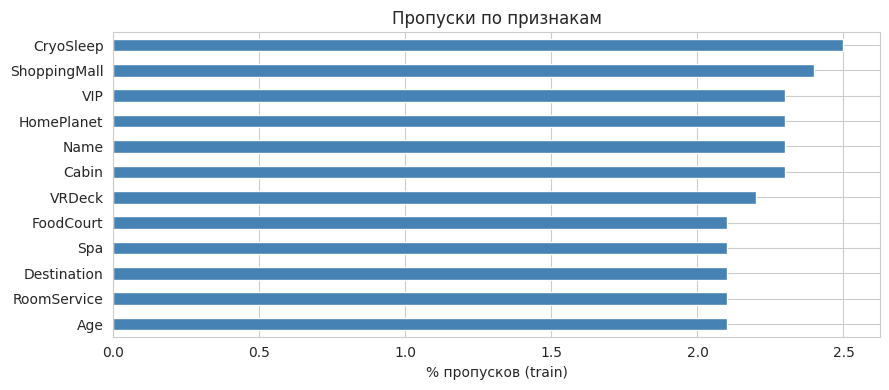


Строк без единого пропуска: 6606 из 8693 


In [2]:
# Пропуски по колонкам (train + test вместе, чтобы видеть общую картину)
missing = pd.DataFrame({
    'train': train.isna().sum(),
    'test': test.reindex(columns=train.columns).isna().sum()
})
missing['train_%'] = (missing['train'] / len(train) * 100).round(1)
missing['test_%']  = (missing['test'] / len(test) * 100).round(1)
missing = missing[missing['train'] > 0].sort_values('train', ascending=False)
print(missing)

fig, ax = plt.subplots(figsize=(9, 4))
missing['train_%'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% пропусков (train)')
ax.set_title('Пропуски по признакам')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nСтрок без единого пропуска: {train.dropna().shape[0]} из {len(train)} ")

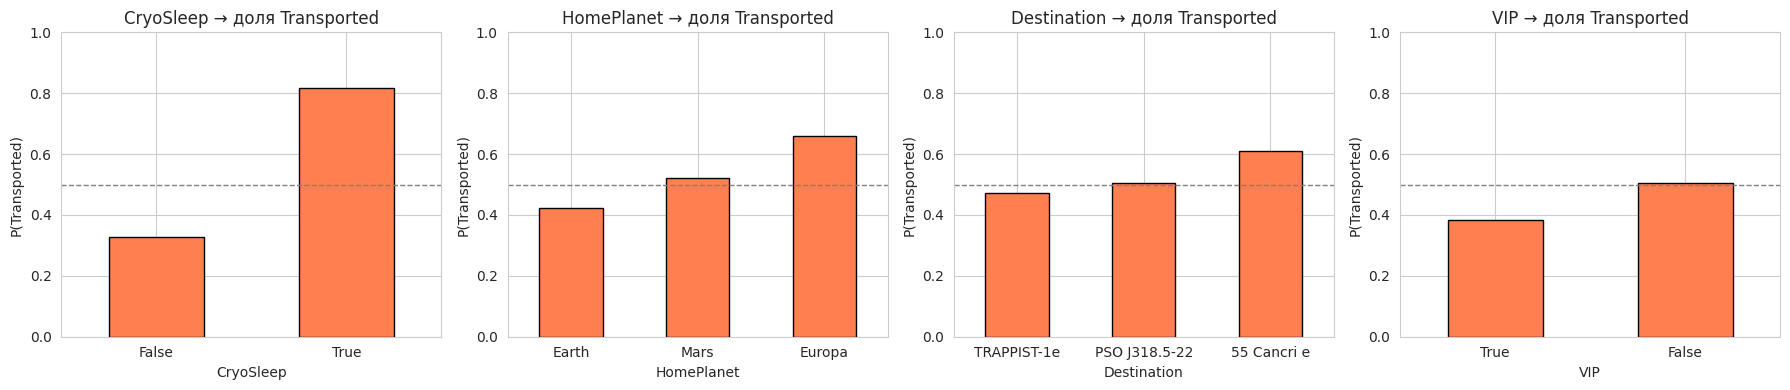


CryoSleep:
            mean  count
CryoSleep              
False      0.329   5439
True       0.818   3037

HomePlanet:
             mean  count
HomePlanet              
Earth       0.424   4602
Europa      0.659   2131
Mars        0.523   1759

Destination:
                mean  count
Destination                
55 Cancri e    0.610   1800
PSO J318.5-22  0.504    796
TRAPPIST-1e    0.471   5915

VIP:
        mean  count
VIP                
False  0.506   8291
True   0.382    199


In [3]:
cat_cols = ['CryoSleep', 'HomePlanet', 'Destination', 'VIP']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, cat_cols):
    rate = train.groupby(col)['Transported'].mean().sort_values()
    rate.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
    ax.axhline(0.5, ls='--', color='gray', lw=1)
    ax.set_title(f'{col} → доля Transported')
    ax.set_ylabel('P(Transported)')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

for col in cat_cols:
    print(f"\n{col}:")
    print(train.groupby(col)['Transported'].agg(['mean', 'count']).round(3))

Корреляция трат с Transported:
  RoomService  : -0.241
  FoodCourt    : +0.046
  ShoppingMall : +0.009
  Spa          : -0.219
  VRDeck       : -0.205

Среди тех, кто потратил 0:  доля Transported = 0.786  (n=3653)
Среди тех, кто потратил >0: доля Transported = 0.299  (n=5040)


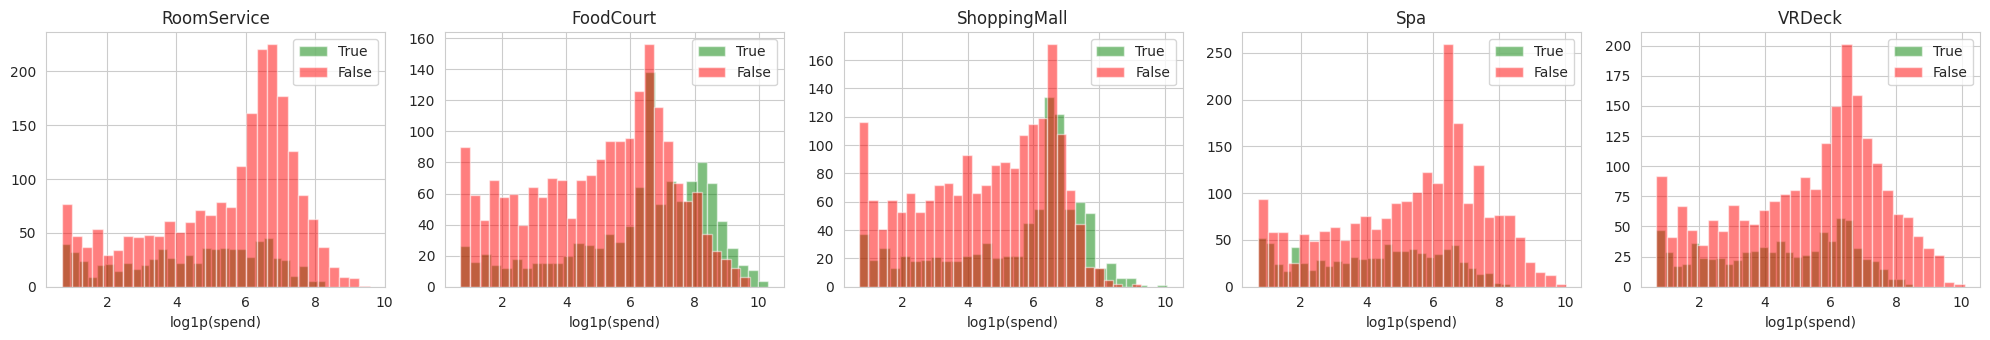

In [4]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

tr = train.copy()
tr['Transported_int'] = tr['Transported'].astype(int)
print("Корреляция трат с Transported:")
for col in spend_cols:
    c = np.corrcoef(tr[col].fillna(0), tr['Transported_int'])[0, 1]
    print(f"  {col:13s}: {c:+.3f}")

tr['TotalSpend'] = tr[spend_cols].fillna(0).sum(axis=1)
print(f"\nСреди тех, кто потратил 0:  доля Transported = "
      f"{tr[tr['TotalSpend']==0]['Transported'].mean():.3f}  (n={ (tr['TotalSpend']==0).sum() })")
print(f"Среди тех, кто потратил >0: доля Transported = "
      f"{tr[tr['TotalSpend']>0]['Transported'].mean():.3f}  (n={ (tr['TotalSpend']>0).sum() })")

fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
for ax, col in zip(axes, spend_cols):
    for val, color in [(True, 'green'), (False, 'red')]:
        data = np.log1p(tr[tr['Transported']==val][col].fillna(0))
        ax.hist(data[data>0], bins=30, alpha=0.5, color=color, label=str(val))
    ax.set_title(col); ax.set_xlabel('log1p(spend)'); ax.legend()
plt.tight_layout()
plt.show()

In [5]:
def parse_structure(df):
    df = df.copy()
    df['Group'] = df['PassengerId'].str.split('_').str[0]
    df['GroupSize'] = df.groupby('Group')['Group'].transform('count')
    cab = df['Cabin'].str.split('/', expand=True)
    df['Deck'], df['CabinNum'], df['Side'] = cab[0], pd.to_numeric(cab[1], errors='coerce'), cab[2]
    return df

full = pd.concat([train.assign(is_train=1),
                  test.assign(is_train=0, Transported=np.nan)], ignore_index=True)
full = parse_structure(full)

multi = full[full['GroupSize'] > 1]
print("Постоянство признаков внутри группы (доля групп, где у всех одно значение):")
for col in ['HomePlanet', 'Side', 'Deck', 'Destination']:
    frac = multi.groupby('Group')[col].apply(lambda x: x.dropna().nunique() <= 1).mean()
    print(f"  {col:12s}: {frac:.1%}")

print(f"\nРаспределение размеров групп:")
print(full.groupby('Group').size().value_counts().sort_index().to_dict())

tr = full[full['is_train'] == 1].copy()
tr['is_solo'] = (tr['GroupSize'] == 1).astype(int)
print(f"\nОдиночки (solo):    Transported = {tr[tr['is_solo']==1]['Transported'].mean():.3f}")
print(f"В группе (>1):      Transported = {tr[tr['is_solo']==0]['Transported'].mean():.3f}")

print(f"\nДоля Transported по Deck:")
print(tr.groupby('Deck')['Transported'].agg(['mean','count']).round(3).to_string())

Постоянство признаков внутри группы (доля групп, где у всех одно значение):
  HomePlanet  : 100.0%
  Side        : 100.0%
  Deck        : 68.5%
  Destination : 49.9%

Распределение размеров групп:
{1: 7145, 2: 1295, 3: 502, 4: 154, 5: 76, 6: 42, 7: 47, 8: 19}

Одиночки (solo):    Transported = 0.452
В группе (>1):      Transported = 0.567

Доля Transported по Deck:
          mean  count
Deck                 
A     0.496094    256
B     0.734275    779
C     0.680054    747
D     0.433054    478
E     0.357306    876
F     0.439871   2794
G     0.516217   2559
T          0.2      5


### Итоги EDA

- CryoSleep - сильнейший предиктор: в криосне переносятся 81.8%, бодрствующие - 32.9%.
- Траты делятся на два типа с противоположным сигналом:Luxury (RoomService, Spa, VRDeck) отрицательно коррелируют с таргетом (−0.20…−0.24), Regular (FoodCourt, ShoppingMall) - около нуля. сделаем раздельные признаки.
- Факт нулевых трат почти так же силён, как CryoSleep.
- Группы: внутри группы (gggg_pp) HomePlanet и Side одинаковы у 100% групп, Deck у 68.5%. Следовательно, заполняем пропуски по группе. Члены групп переносятся чаще одиночек (56.7% и 45.2% соотвественно).
- Deck сильно разделяет таргет: B (73%), C (68%) против E (36%).

## 3. Baseline

* Простая LightGBM (почти дефолт) на сырых признаках с минимальным парсингом Cabin/Group и простейшим заполнением пропусков.
* Валидация - StratifiedGroupKFold(5) с метрикой соревнования (accuracy). От этого числа будем мерить эффект всех улучшений.


In [6]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score
from lightgbm import LGBMClassifier

def basic_prep(df):
    df = df.copy()
    df['Group'] = df['PassengerId'].str.split('_').str[0].astype(int)
    df['GroupSize'] = df.groupby('Group')['Group'].transform('count')
    cab = df['Cabin'].str.split('/', expand=True)
    df['Deck'], df['CabinNum'], df['Side'] = cab[0], pd.to_numeric(cab[1], errors='coerce'), cab[2]
    return df

full_base = pd.concat([train.assign(is_train=1),
                       test.assign(is_train=0, Transported=np.nan)], ignore_index=True)
full_base = basic_prep(full_base)

base_features = ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP',
                 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
                 'Deck', 'CabinNum', 'Side', 'GroupSize']
base_cat = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']

for c in ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']:
    full_base[c] = full_base[c].fillna(0)
full_base['Age'] = full_base['Age'].fillna(full_base['Age'].median())
full_base['CabinNum'] = full_base['CabinNum'].fillna(full_base['CabinNum'].median())
for c in base_cat:
    full_base[c] = full_base[c].astype('object').fillna('Missing').astype('category')

_tr = full_base[full_base['is_train']==1]
Xb, yb = _tr[base_features], _tr['Transported'].astype(int)
gb = _tr['Group'].values

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
oof_base = np.zeros(len(Xb))
for tr_idx, va_idx in sgkf.split(Xb, yb, groups=gb):
    m = LGBMClassifier(n_estimators=300, random_state=42, verbose=-1)
    m.fit(Xb.iloc[tr_idx], yb.iloc[tr_idx])
    oof_base[va_idx] = m.predict_proba(Xb.iloc[va_idx])[:, 1]

baseline_acc = accuracy_score(yb, oof_base > 0.5)
print(f"BASELINE (LightGBM, сырые фичи, 5-fold GroupKFold)")
print(f"CV accuracy: {baseline_acc:.4f}")

BASELINE (LightGBM, сырые фичи, 5-fold GroupKFold)
CV accuracy: 0.8021


## 4. Feature Engineering

In [7]:
def feature_engineering(df):
    df = df.copy()
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

    df['Group'] = df['PassengerId'].str.split('_').str[0].astype(int)
    df['GroupSize'] = df.groupby('Group')['Group'].transform('count')
    cab = df['Cabin'].str.split('/', expand=True)
    df['Deck'], df['CabinNum'], df['Side'] = cab[0], pd.to_numeric(cab[1], errors='coerce'), cab[2]

    df['Cabin_missing']     = df['Cabin'].isna().astype(int)
    df['Name_missing']      = df['Name'].isna().astype(int)
    df['CryoSleep_missing'] = df['CryoSleep'].isna().astype(int)

    # HomePlanet: группа -> правило по Deck -> мода
    df['HomePlanet'] = df.groupby('Group')['HomePlanet'].transform(lambda x: x.ffill().bfill())
    df.loc[df['HomePlanet'].isna() & (df['Deck'] == 'G'), 'HomePlanet'] = 'Earth'
    df.loc[df['HomePlanet'].isna() & df['Deck'].isin(['A','B','C','T']), 'HomePlanet'] = 'Europa'
    df['HomePlanet'] = df['HomePlanet'].fillna(df['HomePlanet'].mode()[0])
    for col in ['Side', 'Deck', 'Destination']:
        df[col] = df.groupby('Group')[col].transform(lambda x: x.ffill().bfill())
        df[col] = df[col].fillna(df[col].mode()[0])

    # CryoSleep
    has_spend = df[spend_cols].sum(axis=1, skipna=True) > 0
    df.loc[df['CryoSleep'].isna() & has_spend, 'CryoSleep'] = False
    df['CryoSleep'] = df.groupby('Group')['CryoSleep'].transform(lambda x: x.ffill().bfill())
    df['CryoSleep'] = df['CryoSleep'].fillna(has_spend.map({True: False}))
    df['CryoSleep'] = df['CryoSleep'].fillna(False).astype(bool)

    df['VIP'] = df['VIP'].fillna(False).astype(bool)
    df['Age'] = df.groupby('HomePlanet')['Age'].transform(lambda x: x.fillna(x.median()))
    df['CabinNum'] = df['CabinNum'].fillna(df['CabinNum'].median())
    df[spend_cols] = df[spend_cols].fillna(0)

    # Траты: Luxury (corr<0) vs Regular (corr~0)
    df['LuxurySpend']  = df['RoomService'] + df['Spa'] + df['VRDeck']
    df['RegularSpend'] = df['FoodCourt'] + df['ShoppingMall']
    df['TotalSpend']   = df[spend_cols].sum(axis=1)
    df['SpentNothing'] = (df['TotalSpend'] == 0).astype(int)
    for col in ['LuxurySpend', 'RegularSpend', 'TotalSpend'] + spend_cols:
        df[f'{col}_log'] = np.log1p(df[col])

    df['is_child'] = (df['Age'] < 13).astype(int)
    df['is_solo']  = (df['GroupSize'] == 1).astype(int)
    df['CabinNum_bin'] = df.groupby('Deck')['CabinNum'].transform(
        lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')).fillna(0)

    df['Group_meanLuxury'] = df.groupby('Group')['LuxurySpend'].transform('mean')
    df['Group_hasChild']   = df.groupby('Group')['is_child'].transform('max')
    df['Group_nDeck']      = df.groupby('Group')['Deck'].transform('nunique')
    return df

full = pd.concat([train.assign(is_train=1),
                  test.assign(is_train=0, Transported=np.nan)], ignore_index=True)
full = feature_engineering(full)
print(f"full shape: {full.shape}   (пропусков в ключевых колонках: "
      f"{full[['HomePlanet','CryoSleep','Destination','Deck','Side','Age','VIP']].isna().sum().sum()})")

full shape: (12970, 41)   (пропусков в ключевых колонках: 0)


Проверим, что FE не вредит: та же LightGBM, но на новых признаках, против baseline.

In [8]:
feature_cols = [
    'HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side',
    'Age', 'is_child', 'is_solo', 'GroupSize', 'CabinNum', 'CabinNum_bin',
    'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
    'LuxurySpend', 'RegularSpend', 'TotalSpend', 'SpentNothing',
    'LuxurySpend_log', 'RegularSpend_log', 'TotalSpend_log',
    'RoomService_log', 'FoodCourt_log', 'ShoppingMall_log', 'Spa_log', 'VRDeck_log',
    'Group_meanLuxury', 'Group_hasChild', 'Group_nDeck',
    'Cabin_missing', 'Name_missing', 'CryoSleep_missing',
]
cat_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']

train_fe = full[full['is_train'] == 1].copy()
test_fe  = full[full['is_train'] == 0].copy()

X = train_fe[feature_cols].copy()
y = train_fe['Transported'].astype(int)
X_test = test_fe[feature_cols].copy()
groups = train_fe['Group'].values

for col in cat_features:
    X[col] = X[col].astype('object').fillna('Missing').astype('category')
    X_test[col] = X_test[col].astype('object').fillna('Missing').astype('category')

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
oof_fe = np.zeros(len(X))
for tr_idx, va_idx in sgkf.split(X, y, groups=groups):
    m = LGBMClassifier(n_estimators=300, random_state=42, verbose=-1)
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_fe[va_idx] = m.predict_proba(X.iloc[va_idx])[:, 1]

fe_acc = accuracy_score(y, oof_fe > 0.5)
print(f"Признаков: {len(feature_cols)} (было {len(base_features)} в baseline)")
print(f"Baseline (сырые фичи): {baseline_acc:.4f}")
print(f"+ Feature Engineering: {fe_acc:.4f}   ({fe_acc - baseline_acc:+.4f})")

Признаков: 35 (было 14 в baseline)
Baseline (сырые фичи): 0.8021
+ Feature Engineering: 0.8063   (+0.0041)


## 5. Кросс-валидация: стратегия и проверка

**Метрика:** accuracy (как в соревновании). **Схема:** `StratifiedGroupKFold(5)`.
- *Stratified* - таргет ~50/50, сохраняем баланс в фолдах.
- *Group* - пассажиры одной группы (`gggg_pp`) не должны попадать одновременно в train и val: их судьбы скоррелированы, иначе утечка.

Ниже сначала задаём конфигурации всех моделей (одно место - чтобы не дублировать), затем проверяем корректность выбора CV: сравниваем наивный `StratifiedKFold` с групповым.

In [9]:
from catboost import CatBoostClassifier
from lightgbm import early_stopping, log_evaluation
from sklearn.ensemble import HistGradientBoostingClassifier

# Конфигурации моделей
lgbm_params = dict(
    n_estimators=2000, learning_rate=0.02, num_leaves=24, subsample=0.8,
    subsample_freq=1, colsample_bytree=0.7, reg_alpha=0.3, reg_lambda=0.3,
    random_state=42, verbose=-1
)
hgb_params = dict(
    max_iter=600, learning_rate=0.05, max_depth=6, l2_regularization=1.0,
    categorical_features='from_dtype', early_stopping=True, random_state=42
)
cat_default_params = dict(
    iterations=2000, learning_rate=0.03, depth=6, l2_leaf_reg=5,
    random_state=42, verbose=0, cat_features=cat_features, eval_metric='Accuracy'
)

In [10]:
from sklearn.model_selection import StratifiedKFold

def cv_accuracy_lgbm(splitter, use_groups):
    oof = np.zeros(len(X))
    splits = splitter.split(X, y, groups=groups) if use_groups else splitter.split(X, y)
    for tr_idx, va_idx in splits:
        m = LGBMClassifier(**lgbm_params)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx], eval_set=[(X.iloc[va_idx], y.iloc[va_idx])],
              eval_metric='binary_logloss',
              callbacks=[early_stopping(150, verbose=False), log_evaluation(0)])
        oof[va_idx] = m.predict_proba(X.iloc[va_idx])[:, 1]
    return accuracy_score(y, oof > 0.5)

acc_naive = cv_accuracy_lgbm(StratifiedKFold(5, shuffle=True, random_state=42), use_groups=False)
acc_group = cv_accuracy_lgbm(StratifiedGroupKFold(5, shuffle=True, random_state=42), use_groups=True)
print(f"Наивный StratifiedKFold (игнор групп): {acc_naive:.4f}")
print(f"Честный StratifiedGroupKFold:          {acc_group:.4f}")
print(f"Разница: {acc_naive - acc_group:+.4f}")

Наивный StratifiedKFold (игнор групп): 0.8164
Честный StratifiedGroupKFold:          0.8133
Разница: +0.0031


Разница мала, потому что мы намеренно не используем target-based групповые фичи (агрегаты считаются из признаков, а не из таргета). `StratifiedGroupKFold` здесь корректный дефолт; он стал бы критичен при вводе target encoding по группам. Плюс baseline CV ≈ исходный public LB - значит валидация честная и CV можно доверять.

## 6. Обучение нескольких моделей

Три модели: 
- CatBoost;
- LightGBM;
- HistGradientBoosting.

Собираем OOF- и test-предсказания, они будут использованы для ансамбля.

In [11]:
N = 5
sgkf = StratifiedGroupKFold(n_splits=N, shuffle=True, random_state=42)

oof_cat = np.zeros(len(X));  test_cat = np.zeros(len(X_test))
oof_lgbm = np.zeros(len(X)); test_lgbm = np.zeros(len(X_test))
oof_hgb = np.zeros(len(X));  test_hgb = np.zeros(len(X_test))

for tr_idx, va_idx in sgkf.split(X, y, groups=groups):
    Xtr, Xva = X.iloc[tr_idx], X.iloc[va_idx]
    ytr, yva = y.iloc[tr_idx], y.iloc[va_idx]

    m_cat = CatBoostClassifier(**cat_default_params)
    m_cat.fit(Xtr, ytr, eval_set=(Xva, yva), early_stopping_rounds=150, use_best_model=True)
    oof_cat[va_idx] = m_cat.predict_proba(Xva)[:, 1]
    test_cat += m_cat.predict_proba(X_test)[:, 1] / N

    m_lgbm = LGBMClassifier(**lgbm_params)
    m_lgbm.fit(Xtr, ytr, eval_set=[(Xva, yva)], eval_metric='binary_logloss',
               callbacks=[early_stopping(150, verbose=False), log_evaluation(0)])
    oof_lgbm[va_idx] = m_lgbm.predict_proba(Xva)[:, 1]
    test_lgbm += m_lgbm.predict_proba(X_test)[:, 1] / N

    m_hgb = HistGradientBoostingClassifier(**hgb_params)
    m_hgb.fit(Xtr, ytr)
    oof_hgb[va_idx] = m_hgb.predict_proba(Xva)[:, 1]
    test_hgb += m_hgb.predict_proba(X_test)[:, 1] / N

acc_cat  = accuracy_score(y, oof_cat  > 0.5)
acc_lgbm = accuracy_score(y, oof_lgbm > 0.5)
acc_hgb  = accuracy_score(y, oof_hgb  > 0.5)
print(f"CatBoost CV: {acc_cat:.4f}")
print(f"LightGBM CV: {acc_lgbm:.4f}")
print(f"HistGB   CV: {acc_hgb:.4f}")

CatBoost CV: 0.8185
LightGBM CV: 0.8133
HistGB   CV: 0.8120


CatBoost лидирует (нативная обработка категорий). Его и берём как основную модель для тюнинга.

## 7. Подбор гиперпараметров (Optuna)

Тюним CatBoost. Сэмплер засижен (`seed=42`) → результат воспроизводим. 

Оптимизируем напрямую accuracy. 

Число трейлов вынесено в константу.

In [12]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_OPTUNA_TRIALS = 25   # на Kaggle ~7-10 мин; можно увеличить

def objective(trial):
    params = dict(
        iterations=2000,
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        depth=trial.suggest_int('depth', 4, 8),
        l2_leaf_reg=trial.suggest_float('l2_leaf_reg', 1, 15, log=True),
        bagging_temperature=trial.suggest_float('bagging_temperature', 0, 1),
        random_strength=trial.suggest_float('random_strength', 0, 3),
        border_count=trial.suggest_int('border_count', 32, 255),
        random_state=42, verbose=0, cat_features=cat_features, eval_metric='Accuracy',
    )
    oof_t = np.zeros(len(X))
    for tr_idx, va_idx in sgkf.split(X, y, groups=groups):
        m = CatBoostClassifier(**params)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx], eval_set=(X.iloc[va_idx], y.iloc[va_idx]),
              early_stopping_rounds=100, use_best_model=True)
        oof_t[va_idx] = m.predict_proba(X.iloc[va_idx])[:, 1]
    return accuracy_score(y, oof_t > 0.5)

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

cat_tuned_params = dict(iterations=2000, random_state=42, verbose=0,
                        cat_features=cat_features, eval_metric='Accuracy',
                        **study.best_params)
print(f"Optuna best CV: {study.best_value:.4f}   (CatBoost без тюнинга: {acc_cat:.4f})")
print("Лучшие параметры:", study.best_params)

  0%|          | 0/25 [00:00<?, ?it/s]

Optuna best CV: 0.8201   (CatBoost без тюнинга: 0.8185)
Лучшие параметры: {'learning_rate': 0.08093263002576821, 'depth': 6, 'l2_leaf_reg': 2.4731811700596884, 'bagging_temperature': 0.35670396970807094, 'random_strength': 2.5994414778748904, 'border_count': 220}


In [13]:
def cat_cv(params, seed=42):
    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    oof = np.zeros(len(X)); test_p = np.zeros(len(X_test))
    p = {**params, 'random_state': seed}
    for tr_idx, va_idx in skf.split(X, y, groups=groups):
        m = CatBoostClassifier(**p)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx], eval_set=(X.iloc[va_idx], y.iloc[va_idx]),
              early_stopping_rounds=150, use_best_model=True)
        oof[va_idx] = m.predict_proba(X.iloc[va_idx])[:, 1]
        test_p += m.predict_proba(X_test)[:, 1] / 5
    return oof, test_p, accuracy_score(y, oof > 0.5)

oof_tuned, test_tuned, acc_tuned = cat_cv(cat_tuned_params)
if acc_tuned >= acc_cat:
    best_cat_params, oof_cat, test_cat, acc_cat_best = cat_tuned_params, oof_tuned, test_tuned, acc_tuned
    print(f"Выбран TUNED CatBoost: {acc_tuned:.4f} (default был {acc_cat:.4f})")
else:
    best_cat_params, acc_cat_best = cat_default_params, acc_cat
    print(f"Выбран DEFAULT CatBoost: {acc_cat:.4f} (tuned дал {acc_tuned:.4f})")

Выбран TUNED CatBoost: 0.8207 (default был 0.8185)


## 8. Ансамбль

Пробуем блендинг лучшего CatBoost с LightGBM и HistGB. Веса подбираем на OOF по сетке. Сначала смотрим корреляцию предсказаний: чем она ниже, тем полезнее ансамбль.

In [14]:
oof_df = pd.DataFrame({'cat': oof_cat, 'lgbm': oof_lgbm, 'hgb': oof_hgb})
print("Корреляция OOF-предсказаний:")
print(oof_df.corr().round(3))

best_blend_acc, best_w = 0, None
for w_cat in np.arange(0, 1.01, 0.05):
    for w_lgbm in np.arange(0, 1.01 - w_cat, 0.05):
        w_hgb = 1 - w_cat - w_lgbm
        if w_hgb < -1e-9:
            continue
        blend = w_cat * oof_cat + w_lgbm * oof_lgbm + w_hgb * oof_hgb
        acc = accuracy_score(y, blend > 0.5)
        if acc > best_blend_acc:
            best_blend_acc, best_w = acc, (round(w_cat, 2), round(w_lgbm, 2), round(w_hgb, 2))

use_blend = best_blend_acc > acc_cat_best + 1e-9
print(f"\nЛучшие веса (cat, lgbm, hgb): {best_w}")
print(f"Ансамбль CV: {best_blend_acc:.4f}   CatBoost соло: {acc_cat_best:.4f}   "
      f"({best_blend_acc - acc_cat_best:+.4f})")
print("Ансамбль лучше соло?" , use_blend)

Корреляция OOF-предсказаний:
        cat   lgbm   hgb
cat   1.000  0.986  0.98
lgbm  0.986  1.000  0.99
hgb   0.980  0.990  1.00

Лучшие веса (cat, lgbm, hgb): (np.float64(1.0), np.float64(0.0), np.float64(0.0))
Ансамбль CV: 0.8207   CatBoost соло: 0.8207   (+0.0000)
Ансамбль лучше соло? False


## 9. Финальное решение и submission

Порог 0.5 (таргет сбалансирован - подбор порога ничего не даёт).

In [15]:
final_seeds = [42, 123, 2024]
test_prob = np.zeros(len(X_test))
oof_final = np.zeros(len(X))

for si, seed in enumerate(final_seeds):
    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    p = {**best_cat_params, 'random_state': seed}
    for tr_idx, va_idx in skf.split(X, y, groups=groups):
        m = CatBoostClassifier(**p)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx], eval_set=(X.iloc[va_idx], y.iloc[va_idx]),
              early_stopping_rounds=150, use_best_model=True)
        if si == 0:
            oof_final[va_idx] = m.predict_proba(X.iloc[va_idx])[:, 1]
        test_prob += m.predict_proba(X_test)[:, 1] / (5 * len(final_seeds))

final_cv = accuracy_score(y, oof_final > 0.5)
print(f"Финальный CV accuracy (seed 42): {final_cv:.4f}")

submission = pd.DataFrame({
    'PassengerId': test_fe['PassengerId'].values,
    'Transported': (test_prob > 0.5).astype(bool)
})
submission.to_csv('submission.csv', index=False)
print(submission['Transported'].value_counts())
submission.head()

Финальный CV accuracy (seed 42): 0.8207
Transported
True     2265
False    2012
Name: count, dtype: int64


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
